### Загрузка проекта из репозитория GitHub

In [ ]:
!git clone https://github.com/sentiyyy/prod_lab1.git
%cd /content/prod_lab1
!git checkout lab_01

### Настройка доступа к локальному модулю

In [2]:
import sys
sys.path.insert(0, "/content/prod_lab1/src")

### Импорт библиотек и пользовательских модулей

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tabulate import tabulate

from model import (
    ConstructiveNumber,
    to_constructive,
    from_constructive,
    QuadraticWellConditioned,
    QuadraticPoorConditioned,
    RosenbrockFunction,
    NelderMead,
    GradientDescent,
    NewtonMethod,
)

from utils import (
    seed_everything,
    condition_number,
    run_experiment,
    track_eps_during_optimization,
    print_results_table_custom,
    plot_convergence,
    plot_trajectory_2d,
    plot_eps_dynamics
)

seed_everything(42)

---
## Блок 1: Конструктивное число

Конструктивное число - интервал [a, b] ∈ Q, который «содержит» нужное нам вещественное число.  
Ширина интервала ε = b − a - наша точность: чем меньше, тем точнее.

In [4]:
# Способ 1: из вещественного числа с заданной точностью ε
pi_approx = ConstructiveNumber.from_real(3.14159, eps=0.001)
print('π ≈', pi_approx)
print('Значение при α=0:', pi_approx.get_value(alpha=0))
print('Значение при α=0.5:', pi_approx.get_value(alpha=0.5))
print('Значение при α=1:', pi_approx.get_value(alpha=1))
print()

# Способ 2: сразу задать границы a, b
a = ConstructiveNumber(2.0, 2.5)
b = ConstructiveNumber(3.0, 3.5)
print('a =', a)
print('b =', b)
print()
print('a + b =', a + b)
print('a - b =', a - b)
print('a * b =', a * b)
print('a / b =', a / b)
print('a + 1.0 =', a + 1.0)
print('2.0 * a =', 2.0 * a)
print('a < b ?', a < b)
print('a > b ?', a > b)

π ≈ ConstructiveNumber([3.14109, 3.14209], ε=1.00e-03)
Значение при α=0: 3.1410899999999997
Значение при α=0.5: 3.14159
Значение при α=1: 3.14209

a = ConstructiveNumber([2, 2.5], ε=5.00e-01)
b = ConstructiveNumber([3, 3.5], ε=5.00e-01)

a + b = ConstructiveNumber([5, 6], ε=1.00e+00)
a - b = ConstructiveNumber([-1.5, -0.5], ε=1.00e+00)
a * b = ConstructiveNumber([6, 8.75], ε=2.75e+00)
a / b = ConstructiveNumber([0.571429, 0.833333], ε=2.62e-01)
a + 1.0 = ConstructiveNumber([3, 3.5], ε=5.00e-01)
2.0 * a = ConstructiveNumber([4, 5], ε=1.00e+00)
a < b ? True
a > b ? False


In [5]:
# Накопление погрешности: при каждой операции ε растёт
x = ConstructiveNumber.from_real(1.0, eps=1e-4)
print(f'x:            ε = {x.eps:.2e}')
print(f'x + x:        ε = {(x + x).eps:.2e}') # ε удваивается
print(f'x * x:        ε = {(x * x).eps:.2e}') # ε тоже растёт

acc = ConstructiveNumber.from_real(1.0, eps=1e-6)
for _ in range(10):
    acc = acc + ConstructiveNumber.from_real(1.0, eps=1e-6)
print(f'После 10 сложений: ε = {acc.eps:.2e}')

x:            ε = 1.00e-04
x + x:        ε = 2.00e-04
x * x:        ε = 2.00e-04
После 10 сложений: ε = 1.10e-05


In [6]:
# Дополнительная операция, проверка корректности работы на интервале
x = ConstructiveNumber(-3, 2)
print("x:", x)

y = abs(x)
print("abs(x):", y)

# Проверим реальные значения внутри интервала
test_points = [-3, -1, 0, 1, 2]
abs_values = [abs(t) for t in test_points]

print("Реальные |x| в интервале:", abs_values)
print("Минимум:", min(abs_values))
print("Максимум:", max(abs_values))

x: ConstructiveNumber([-3, 2], ε=5.00e+00)
abs(x): ConstructiveNumber([0, 3], ε=3.00e+00)
Реальные |x| в интервале: [3, 1, 0, 1, 2]
Минимум: 0
Максимум: 3


---
## Блок 2: Чёрные ящики

Все три функции используют единый интерфейс (`__call__`, `gradient`, счётчики вызовов).

| Функция | Размерность | Обусловленность | Минимум |
|---------|-------------|-----------------|--------|
| `QuadraticWellConditioned` | 6 | ≈ 1 | (1,2,3,4,5,6) |
| `QuadraticPoorConditioned` | 4 | ≈ 100 | (1,2,3,4) |
| `RosenbrockFunction` | 3 | — | (1,1,1) |

In [7]:
# Проверяем корректность функций, численную сложность (обусловленность)
f_good = QuadraticWellConditioned()
f_bad = QuadraticPoorConditioned()
f_rosen = RosenbrockFunction()

print('f_good в минимуме:', f_good(f_good.center))
print('f_bad в минимуме:', f_bad(f_bad.center))
print('Розенброк в (1,1,1):', f_rosen(np.array([1.0, 1.0, 1.0])))
print()

cond_good = condition_number(f_good, f_good.center + 0.1)
cond_bad = condition_number(f_bad, f_bad.center + 0.1)
print(f'Обусловленность f_good: {cond_good:.2f} (хотим ≈ 1)')
print(f'Обусловленность f_bad:  {cond_bad:.2f} (хотим ≈ 100)')

x_cn_bad = to_constructive([0.0, 0.0, 0.0, 0.0], eps=1e-4)
res_bad_cn = f_bad(x_cn_bad)
print('\nРезультат f_bad на конструктивных числах:', res_bad_cn)

x_cn_rosen = to_constructive([0.0, 0.0, 0.0], eps=1e-4)
res_rosen_cn = f_rosen(x_cn_rosen)
print('Результат Rosenbrock на конструктивных числах:', res_rosen_cn.get_value())

f_good в минимуме: 0.0
f_bad в минимуме: 0.0
Розенброк в (1,1,1): 0.0

Обусловленность f_good: 1.22 (хотим ≈ 1)
Обусловленность f_bad:  100.00 (хотим ≈ 100)

Результат f_bad на конструктивных числах: ConstructiveNumber([2090.94, 2091.06], ε=1.14e-01)
Результат Rosenbrock на конструктивных числах: 2.0000000050000004


In [8]:
# Проверяем совместимость с конструктивными числами
x_cn_bad = to_constructive([0.0, 0.0, 0.0, 0.0], eps=1e-4)
res_bad_cn = f_bad(x_cn_bad)

print("f_bad на конструктивных числах:")
print(res_bad_cn)
print("Тип:", type(res_bad_cn))
print("Значение при α=0.5:", res_bad_cn.get_value())

f_bad на конструктивных числах:
ConstructiveNumber([2090.94, 2091.06], ε=1.14e-01)
Тип: <class 'model.ConstructiveNumber'>
Значение при α=0.5: 2091.0000004025


In [9]:
# Дополнительная проверка совместимости функции Розенброка с конструктивными числами
x_cn_rosen = to_constructive([0.0, 0.0, 0.0], eps=1e-4)
res_rosen_cn = f_rosen(x_cn_rosen)

print("Rosenbrock на конструктивных числах:")
print(res_rosen_cn)
print("Тип:", type(res_rosen_cn))
print("Значение при α=0.5:", res_rosen_cn.get_value())

Rosenbrock на конструктивных числах:
ConstructiveNumber([1.9998, 2.0002], ε=4.01e-04)
Тип: <class 'model.ConstructiveNumber'>
Значение при α=0.5: 2.0000000050000004


---
## Блок 3: Методы оптимизации

**Нелдер-Мид (0-й порядок)** - строит симплекс из n+1 вершин и деформирует его (отражение, расширение, сжатие). Производные не нужны.

**Градиентный спуск (1-й порядок)** - шагает против градиента: **x** ← **x** − lr · ∇f(**x**).  
Поддерживаем фиксированный шаг и backtracking line search (условие Армихо).

In [10]:
f_good = QuadraticWellConditioned()
x_start_6 = np.zeros(6)

# Метод 0-го порядка: Nelder-Mead
nm = NelderMead(tol=1e-8, max_iter=5000)
res_nm = nm.optimize(f_good, x_start_6)

print("=== Nelder-Mead ===")
print(res_nm)
print(f"Найденный минимум: {res_nm.x_opt}")
print(f"Истинный минимум:  {f_good.center}")
print(f"Расстояние до минимума: {np.linalg.norm(res_nm.x_opt - f_good.center):.2e}")
print(f"Вызовов функции: {f_good.call_count}")

=== Nelder-Mead ===
[Нелдер-Мид (0-й порядок)] сошёлся за 462 итераций, f(x*) = 2.18075e-17
Найденный минимум: [1. 2. 3. 4. 5. 6.]
Истинный минимум:  [1. 2. 3. 4. 5. 6.]
Расстояние до минимума: 4.65e-09
Вызовов функции: 740


In [11]:
f_good_gd = QuadraticWellConditioned()
x_start_6 = np.zeros(6)

# 1) фиксированный шаг
gd_fixed = GradientDescent(
    lr=0.1,
    lr_strategy='fixed',
    tol=1e-8,
    max_iter=5000
)

res_gd_fixed = gd_fixed.optimize(f_good_gd, x_start_6)

print("Фиксированный lr=0.1:")
print(res_gd_fixed)
print(f"Вызовов функции: {f_good_gd.call_count}, градиентов: {f_good_gd.grad_count}")
print()

# 2) backtracking
f_good_gd2 = QuadraticWellConditioned()

gd_bt = GradientDescent(
    lr=1.0,
    lr_strategy='backtracking',
    tol=1e-8,
    max_iter=5000
)

res_gd_bt = gd_bt.optimize(f_good_gd2, x_start_6)

print("Backtracking line search:")
print(res_gd_bt)
print(f"Вызовов функции: {f_good_gd2.call_count}, градиентов: {f_good_gd2.grad_count}")

Фиксированный lr=0.1:
[Градиентный спуск (lr=0.1, стратегия=fixed)] сошёлся за 53 итераций, f(x*) = 1.40954e-08
Вызовов функции: 55, градиентов: 54

Backtracking line search:
[Градиентный спуск (lr=1.0, стратегия=backtracking)] сошёлся за 7 итераций, f(x*) = 2.3472e-11
Вызовов функции: 29, градиентов: 8


---
## Блок 4: Исследование

Визуализируем, как работают наши методы на различных функциях

In [12]:
# Запускаем оба метода на всех трёх функциях и собираем метрики
functions = [
    (QuadraticWellConditioned(), np.zeros(6), np.array([1., 2., 3., 4., 5., 6.])),
    (QuadraticPoorConditioned(), np.zeros(4), np.array([1., 2., 3., 4.])),
    (RosenbrockFunction(), np.full(3, -1.0), np.array([1., 1., 1.])),
]

all_results = []

for func, x0, true_min in functions:
    all_results.append(run_experiment(func, NelderMead(tol=1e-8, max_iter=10000), x0, true_min))
    all_results.append(run_experiment(func, GradientDescent(lr=0.5, lr_strategy='backtracking', tol=1e-8, max_iter=10000), x0, true_min))

print_results_table_custom(all_results)

+----------------------------------------------------+------------------------------+-----------+---------+------------+---------------+------------+-----------+
| Метод                                              | Функция                      |     f(x*) |   Итер. |   Вызовы f |   Вызовы grad |   Время, с | Сошёлся   |
+====================================================+==============================+===========+=========+============+===============+============+===========+
| Нелдер-Мид (0-й порядок)                           | Квадратичная_6мерная_хорошая | 2.181e-17 |     462 |        740 |             0 |     0.1081 | да        |
+----------------------------------------------------+------------------------------+-----------+---------+------------+---------------+------------+-----------+
| Градиентный спуск (lr=0.5, стратегия=backtracking) | Квадратичная_6мерная_хорошая | 2.43e-11  |       6 |         20 |             7 |     0.0006 | да        |
+---------------------------

+------------------------------------------------+-----------------------------+-----------+---------+------------+---------------+------------+-----------+
| Метод                                          | Функция                     |     f(x*) |   Итер. |   Вызовы f |   Вызовы grad |   Время, с | Сошёлся   |
+================================================+=============================+===========+=========+============+===============+============+===========+
| Градиентный спуск (lr=0.0001, стратегия=fixed) | Квадратичная_4мерная_плохая | 0.1353    |    5000 |       5002 |          5000 |     0.2875 | нет       |
+------------------------------------------------+-----------------------------+-----------+---------+------------+---------------+------------+-----------+
| Градиентный спуск (lr=0.0005, стратегия=fixed) | Квадратичная_4мерная_плохая | 4.517e-05 |    5000 |       5002 |          5000 |     0.1894 | нет       |
+------------------------------------------------+--------

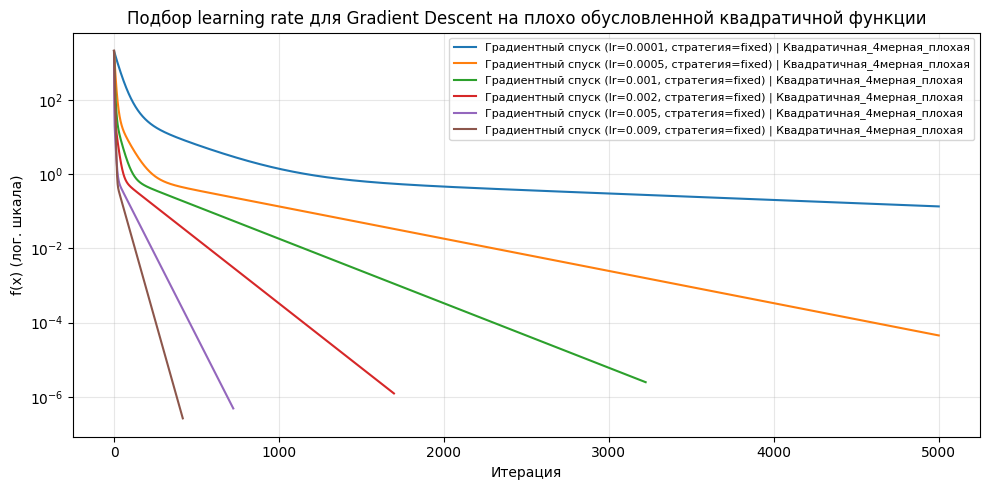

In [13]:
# Исследование влияния learning rate
lrs = [1e-4, 5e-4, 1e-3, 2e-3, 5e-3, 9e-3]

func = QuadraticPoorConditioned()
x0 = np.zeros(4)
true_min = np.array([1., 2., 3., 4.])

lr_results = []

for lr in lrs:
    lr_results.append(
        run_experiment(func, GradientDescent(lr=lr, lr_strategy="fixed", tol=1e-8, max_iter=5000), x0, true_min)
    )

print_results_table_custom(lr_results)

plot_convergence(lr_results, title="Подбор learning rate для Gradient Descent на плохо обусловленной квадратичной функции")

Для плохо обусловленной квадратичной функции качество градиентного спуска сильно зависит от learning rate. При слишком малых значениях шага (`1e-4`, `5e-4`, `1e-3`) метод движется к минимуму, но делает это слишком медленно и не успевает сойтись за заданное число итераций. При шагах `0.002`, `0.005` и `0.009` метод уже сходится, причём наилучший результат по числу итераций даёт `lr = 0.009`. Это согласуется с теорией: для данной функции шаг должен быть меньше критического значения порядка `0.01`, и наилучшая скорость достигается при выборе шага, близкого к верхней границе устойчивости.


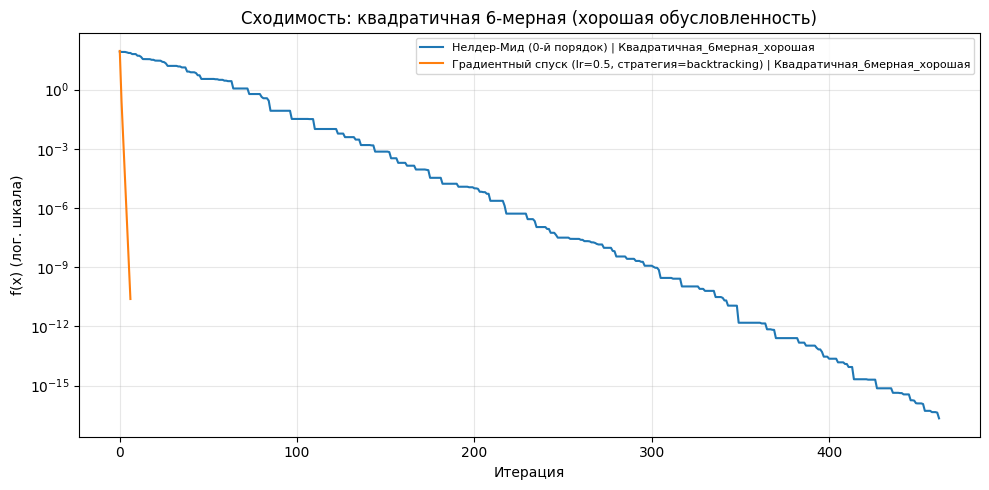

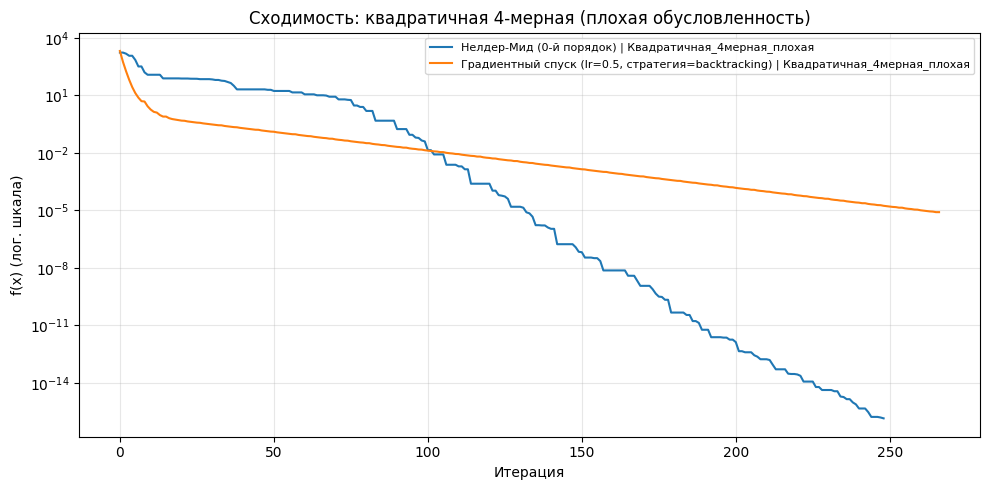

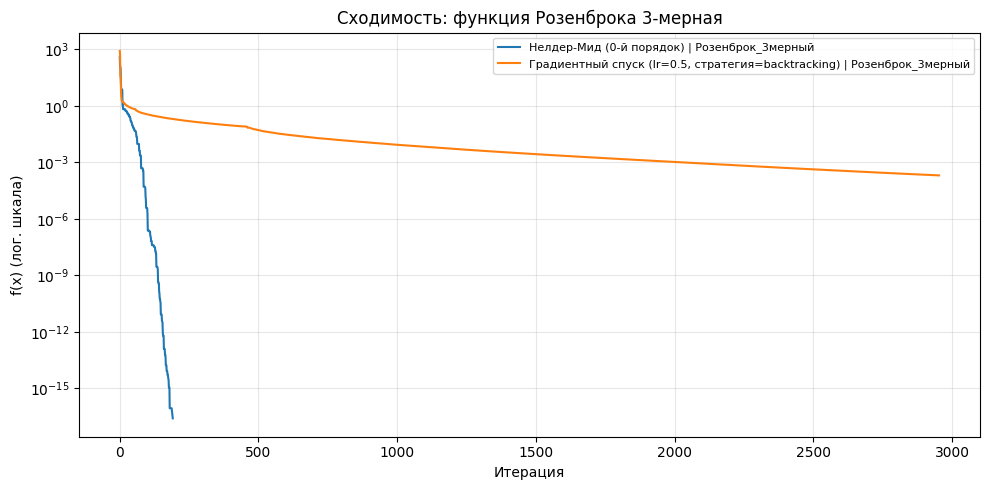

In [14]:
# Cравнение скорости сходимости методов оптимизации на трёх типах задач:
plot_convergence(
    [r for r in all_results if '6' in r['func_name']],
    title='Сходимость: квадратичная 6-мерная (хорошая обусловленность)'
)

plot_convergence(
    [r for r in all_results if '4' in r['func_name']],
    title='Сходимость: квадратичная 4-мерная (плохая обусловленность)'
)

plot_convergence(
    [r for r in all_results if 'Розенброк' in r['func_name']],
    title='Сходимость: функция Розенброка 3-мерная'
)

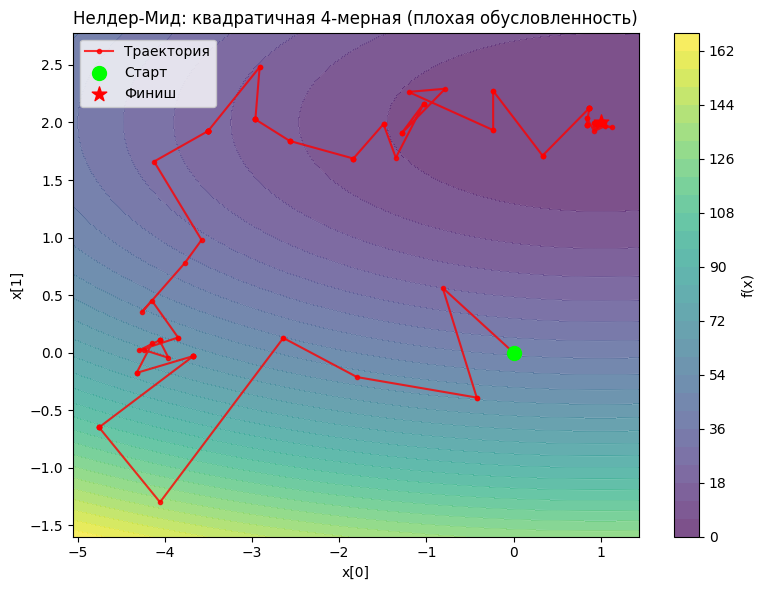

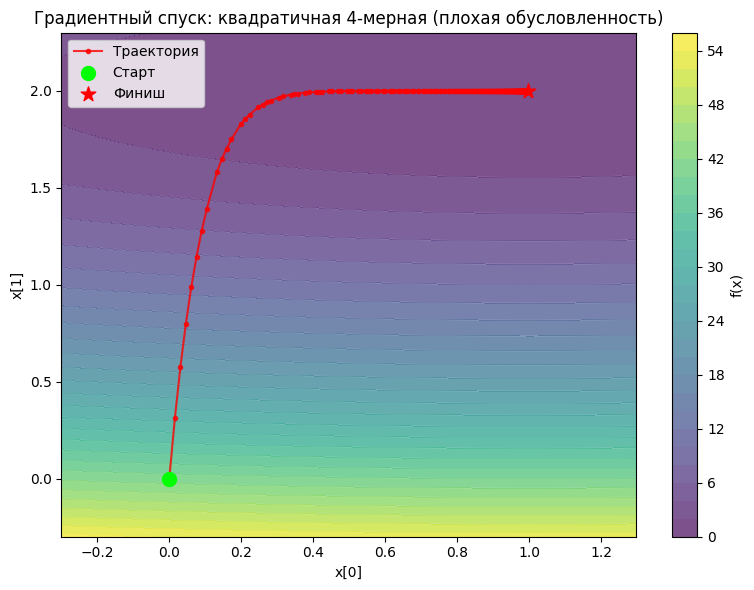

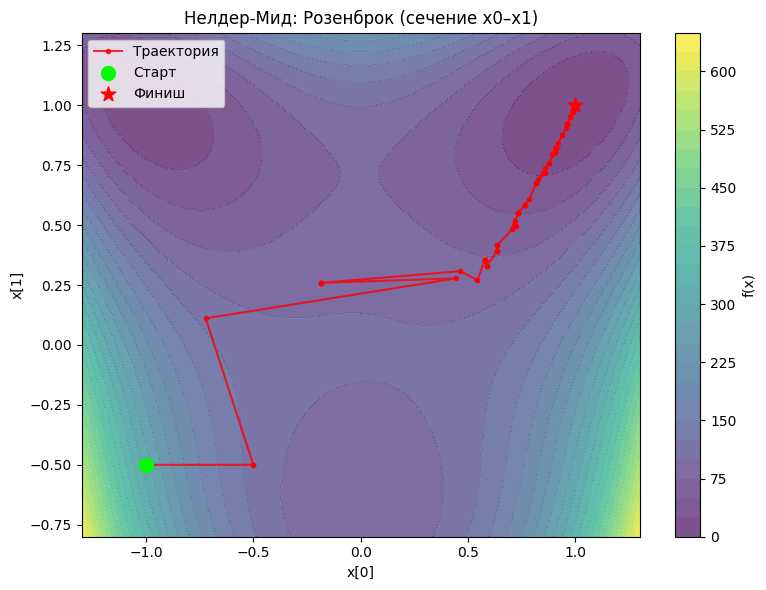

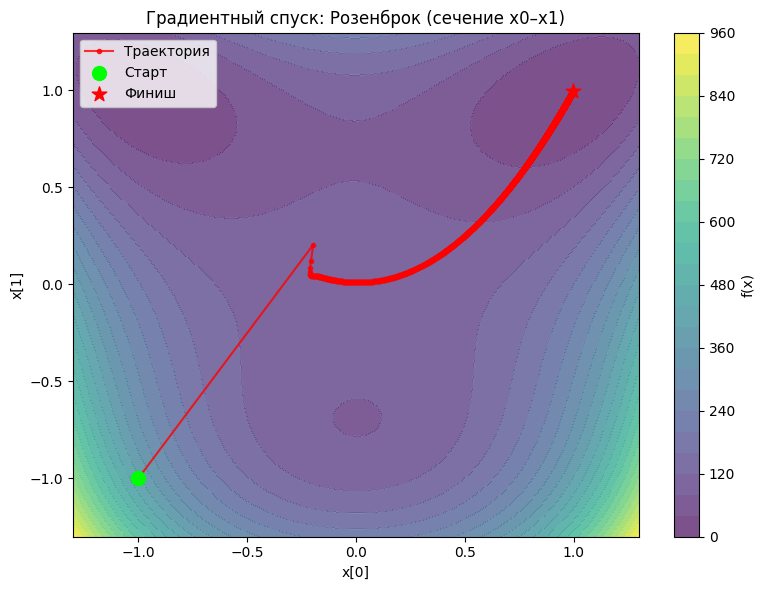

In [15]:
# Визуализация траекторий сходимости методов
f_bad = QuadraticPoorConditioned()
x_start_4 = np.zeros(4)

nm_bad = NelderMead(tol=1e-8, max_iter=5000)
res_nm_bad = nm_bad.optimize(f_bad, x_start_4)

plot_trajectory_2d(
    f_bad,
    res_nm_bad,
    axis_indices=(0, 1),
    title='Нелдер-Мид: квадратичная 4-мерная (плохая обусловленность)'
)

gd_bad = GradientDescent(lr=0.5, lr_strategy='backtracking', tol=1e-8, max_iter=5000)
res_gd_bad = gd_bad.optimize(f_bad, x_start_4)

plot_trajectory_2d(
    f_bad,
    res_gd_bad,
    axis_indices=(0, 1),
    title='Градиентный спуск: квадратичная 4-мерная (плохая обусловленность)'
)

f_rosen = RosenbrockFunction()
x_start_rosen = np.full(3, -1.0)

nm_rosen = NelderMead(tol=1e-9, max_iter=10000)
res_nm_rosen = nm_rosen.optimize(f_rosen, x_start_rosen)

plot_trajectory_2d(
    f_rosen,
    res_nm_rosen,
    axis_indices=(0, 1),
    title='Нелдер-Мид: Розенброк (сечение x0–x1)'
)

gd_rosen = GradientDescent(lr=0.001, lr_strategy='backtracking', tol=1e-8, max_iter=10000)
res_gd_rosen = gd_rosen.optimize(f_rosen, x_start_rosen)

plot_trajectory_2d(
    f_rosen,
    res_gd_rosen,
    axis_indices=(0, 1),
    title='Градиентный спуск: Розенброк (сечение x0–x1)'
)

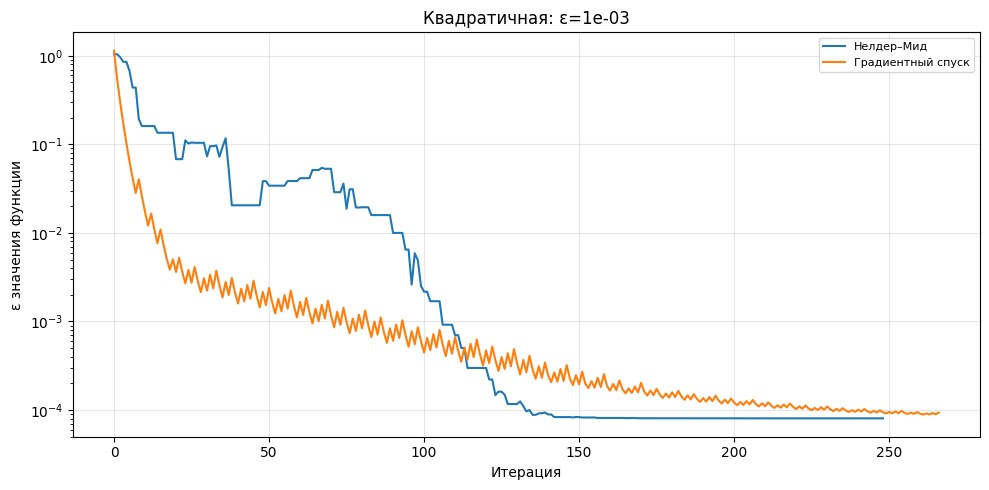

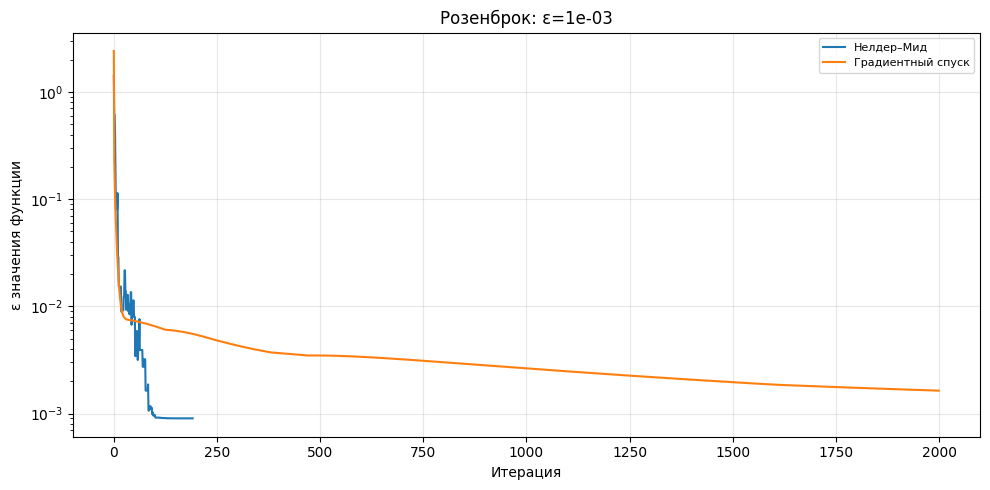

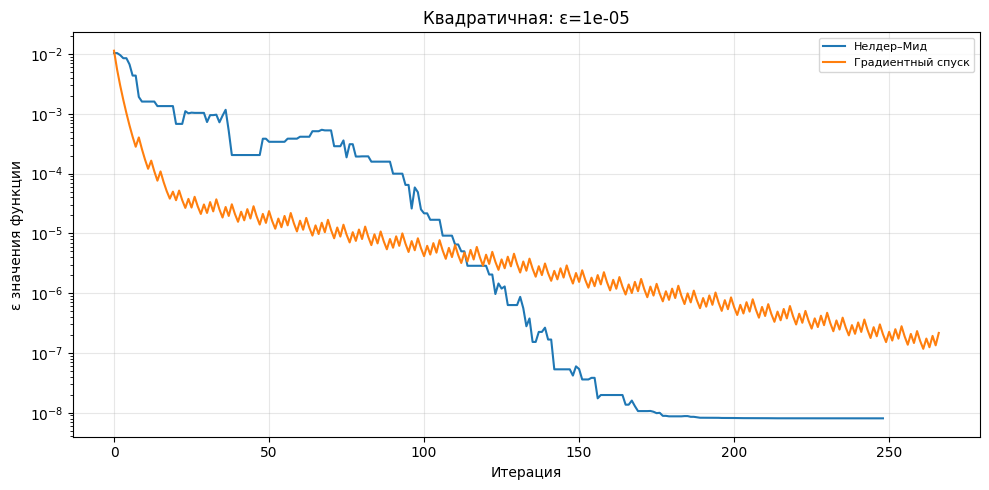

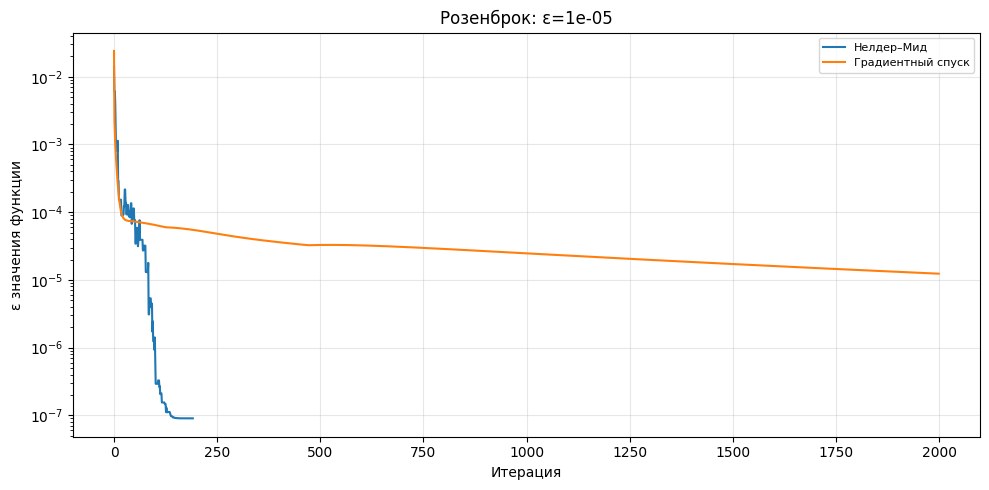

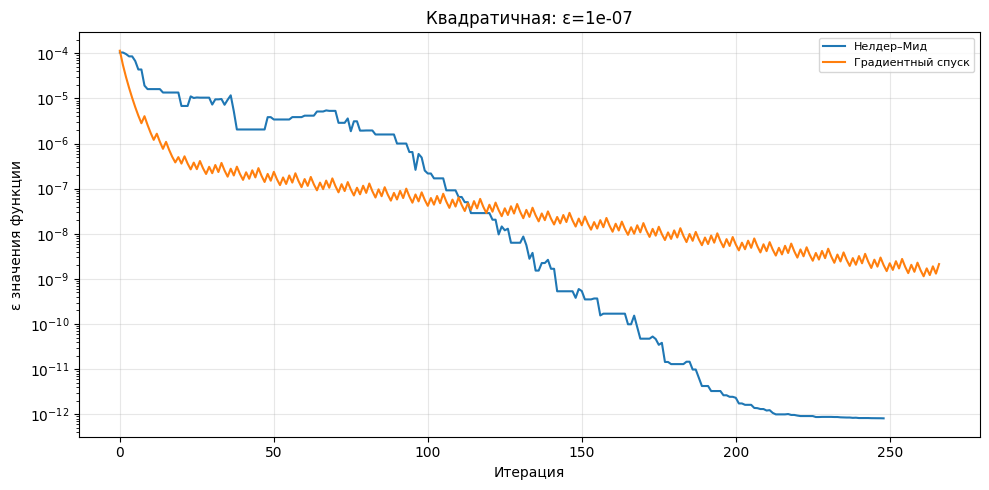

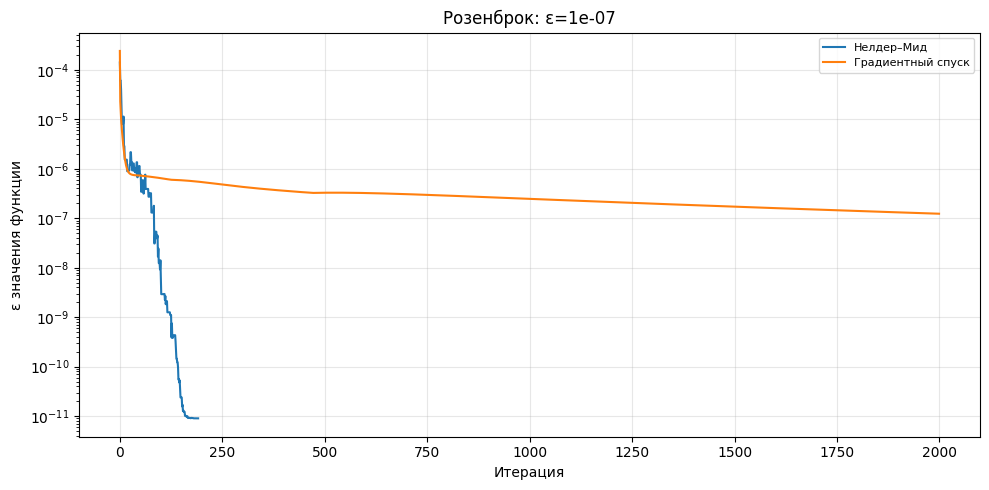

In [16]:
# Анализ влияния начального ε на сходимость методов оптимизации для разных тестовых функций
eps_levels = [1e-3, 1e-5, 1e-7] # Значения начального ε для анализа чувствительности сходимости

# Тестовые функции
f_quad = QuadraticPoorConditioned()
f_rosen = RosenbrockFunction()

# Эксперименты на квадратичной плохо обусловленной функции
quad_experiments = [
    ("Нелдер–Мид", NelderMead(tol=1e-8, max_iter=5000), np.zeros(4)),
    ("Градиентный спуск", GradientDescent(lr=0.5, lr_strategy="backtracking", tol=1e-8, max_iter=5000), np.zeros(4)),
]

# Эксперименты на функции Розенброка
rosen_experiments = [
    ("Нелдер–Мид", NelderMead(tol=1e-8, max_iter=10000), np.full(3, -1.0)),
    ("Градиентный спуск", GradientDescent(lr=0.001, lr_strategy="backtracking", tol=1e-8, max_iter=10000), np.full(3, -1.0)),
]

for eps in eps_levels:
    quad_hist, quad_labels = [], []
    for label, method, x0 in quad_experiments:
        res = method.optimize(f_quad, x0)
        quad_hist.append(track_eps_during_optimization(f_quad, res, eps_init=eps))
        quad_labels.append(label)

    plot_eps_dynamics(
        quad_hist,
        quad_labels,
        title=f"Квадратичная: ε={eps:.0e}",
        max_iter_to_show=1200
    )

    rosen_hist, rosen_labels = [], []
    for label, method, x0 in rosen_experiments:
        res = method.optimize(f_rosen, x0)
        rosen_hist.append(track_eps_during_optimization(f_rosen, res, eps_init=eps))
        rosen_labels.append(label)

    plot_eps_dynamics(
        rosen_hist,
        rosen_labels,
        title=f"Розенброк: ε={eps:.0e}",
        max_iter_to_show=2000
    )

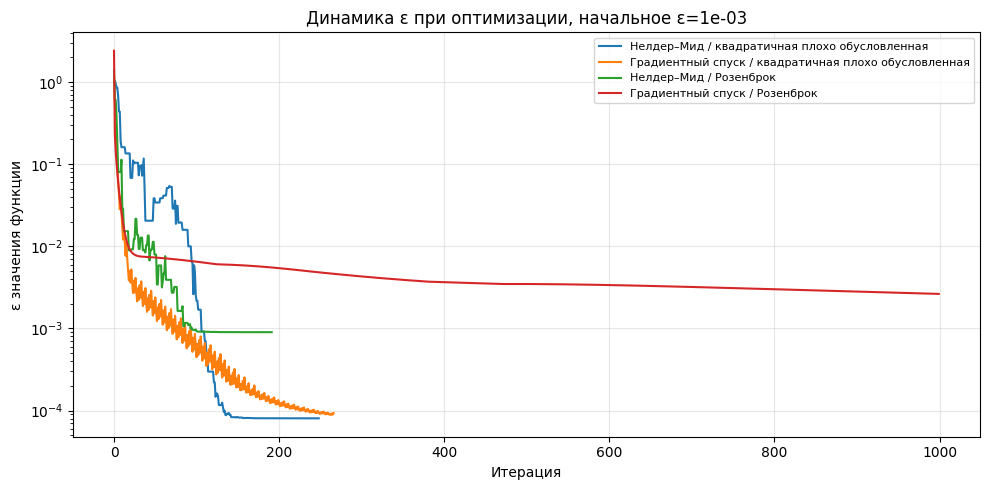

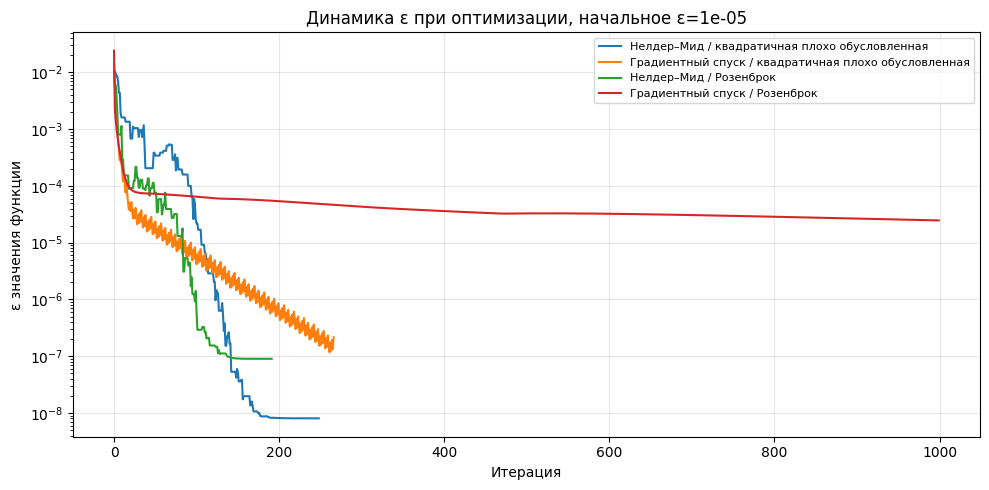

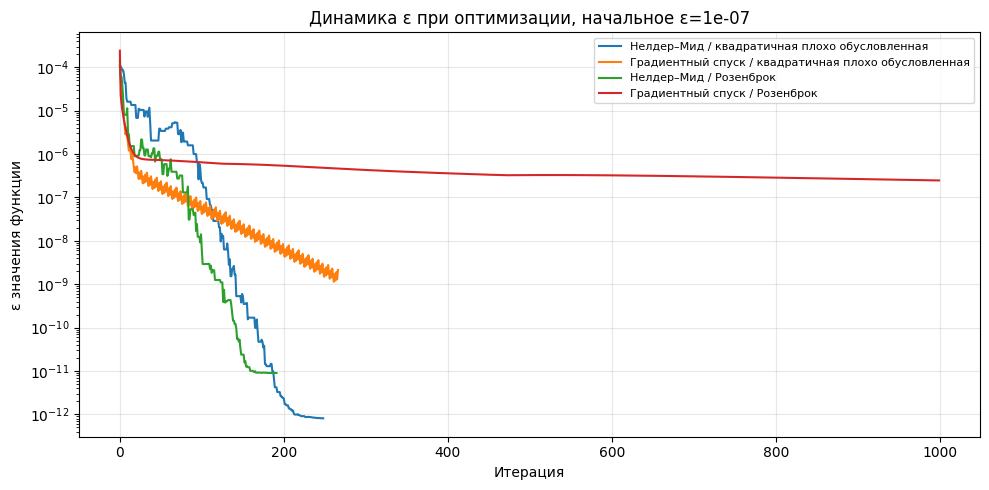

In [17]:
# Анализ влияния начального ε на сходимость методов оптимизации (унифицированный эксперимент)
eps_levels = [1e-3, 1e-5, 1e-7]

eps_experiments = [
    (
        "Нелдер–Мид / квадратичная плохо обусловленная",
        QuadraticPoorConditioned(),
        NelderMead(tol=1e-8, max_iter=5000),
        np.zeros(4),
    ),
    (
        "Градиентный спуск / квадратичная плохо обусловленная",
        QuadraticPoorConditioned(),
        GradientDescent(lr=0.5, lr_strategy="backtracking", tol=1e-8, max_iter=5000),
        np.zeros(4),
    ),
    (
        "Нелдер–Мид / Розенброк",
        RosenbrockFunction(),
        NelderMead(tol=1e-8, max_iter=10000),
        np.full(3, -1.0),
    ),
    (
        "Градиентный спуск / Розенброк",
        RosenbrockFunction(),
        GradientDescent(lr=0.001, lr_strategy="backtracking", tol=1e-8, max_iter=10000),
        np.full(3, -1.0),
    ),
]

for eps in eps_levels:
    eps_histories = []
    labels = []

    for label, func, method, x0 in eps_experiments:
        result = method.optimize(func, x0)
        eps_hist = track_eps_during_optimization(func, result, eps_init=eps)
        eps_histories.append(eps_hist)
        labels.append(label)

    plot_eps_dynamics(
        eps_histories,
        labels,
        title=f"Динамика ε при оптимизации, начальное ε={eps:.0e}",
        max_iter_to_show=1000
    )

In [18]:
# Экспериментальная оценка метода Ньютона на тестовых функциях
newton_results = []

functions_for_newton = [
    (QuadraticWellConditioned(), np.zeros(6), np.array([1., 2., 3., 4., 5., 6.])),
    (QuadraticPoorConditioned(), np.zeros(4), np.array([1., 2., 3., 4.])),
    (RosenbrockFunction(), np.array([-1.2, 1.0, 0.5]), np.array([1., 1., 1.])),
]

for func, x_start, true_min in functions_for_newton:
    newton = NewtonMethod(lr=1.0, tol=1e-8, max_iter=100)
    newton_results.append(run_experiment(func, newton, x_start, true_min))

print_results_table_custom(newton_results)

+------------------------+------------------------------+-----------+---------+------------+---------------+------------+-----------+
| Метод                  | Функция                      |     f(x*) |   Итер. |   Вызовы f |   Вызовы grad |   Время, с | Сошёлся   |
+========================+==============================+===========+=========+============+===============+============+===========+
| Метод Ньютона (lr=1.0) | Квадратичная_6мерная_хорошая | 0         |       1 |          3 |             2 |     0.001  | да        |
+------------------------+------------------------------+-----------+---------+------------+---------------+------------+-----------+
| Метод Ньютона (lr=1.0) | Квадратичная_4мерная_плохая  | 0         |       1 |          3 |             2 |     0.0002 | да        |
+------------------------+------------------------------+-----------+---------+------------+---------------+------------+-----------+
| Метод Ньютона (lr=1.0) | Розенброк_3мерный            | 1.23